
# Novel Contribution: Multimodal Siamese Architecture (Visual + OCR)
This notebook implements an advanced Dual-Stream Siamese-inspired architecture comparing Visual Features and Optical Character Recognition (OCR) error metrics against a 'Golden Reference' baseline.

**Train Set:** 4072 Images
**Test Set:** 65 Images


In [6]:

import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from ultralytics import YOLO
from skimage.feature import graycomatrix, graycoprops
import pytesseract
# pip install python-Levenshtein
import Levenshtein

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import joblib

# If pytesseract is not in PATH, you may need to point it to the executable path
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

print('All imports successful.')


All imports successful.


In [7]:

base_path = '.'
splits = ['train', 'valid', 'test']

for split in splits:
    img_path = os.path.join(base_path, split, 'images')
    if os.path.exists(img_path):
        num_images = len(os.listdir(img_path))
        print(f'{split.upper()}: Images={num_images}')


TRAIN: Images=4072
VALID: Images=122
TEST: Images=65



## 1. Localize and Extract ROI using YOLOv8
We must run YOLO specifically on the `train` (4072) and `test` (65) folders to maintain strict data separation!


In [8]:

yolo_model = YOLO('runs/detect/train13/weights/best.pt')

# Function to extract ROI from an image using YOLO
def extract_pill_roi(img_path, model):
    results = model.predict(source=img_path, conf=0.25, verbose=False)
    img = cv2.imread(img_path)
    if img is None: return None
    
    # Grab the highest confidence bounding box
    if len(results[0].boxes) > 0:
        box = results[0].boxes[0].xyxy[0].cpu().numpy().astype(int)
        x1, y1, x2, y2 = box
        crop = img[y1:y2, x1:x2]
        return crop
    return img # fallback to original if nothing detected



## 2. Dual Stream Extraction Modules
- **Stream A (Visual):** 13 Features (Color, Texture, Shape)
- **Stream B (OCR):** Text parsing


In [9]:

def extract_visual_features(crop):
    features = []
    # --- Color ---
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    mean = np.mean(crop_rgb, axis=(0,1))
    std = np.std(crop_rgb, axis=(0,1))
    features.extend([mean[0], mean[1], mean[2], std[0], std[1], std[2]])
    
    # --- Texture ---
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray_res = cv2.resize(gray, (256, 256))
    glcm = graycomatrix(gray_res, distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    features.extend([
        graycoprops(glcm, 'contrast')[0, 0],
        graycoprops(glcm, 'energy')[0, 0],
        graycoprops(glcm, 'homogeneity')[0, 0],
        graycoprops(glcm, 'correlation')[0, 0]
    ])
    
    # --- Shape ---
    _, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(contours) > 0:
        cnt = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(cnt)
        features.extend([cv2.contourArea(cnt), cv2.arcLength(cnt, True), float(w)/h if h!=0 else 0])
    else:
        features.extend([0, 0, 0])
        
    return np.array(features)

def extract_ocr_text(crop):
    # Basic pre-processing for OCR
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    text = pytesseract.image_to_string(gray, config='--psm 6').strip()
    return text



## 3. Generate Distance Metrics (The Siamese Approach)
We compare every image against a 'Golden Reference' Genuine image. 
Instead of feeding raw features into the model, we feed the **Absolute Difference** between the True Reference and the Sample.


In [10]:

# Choose a reference image (A known perfect genuine pill from the train set)
# We assume the first class 0 image is perfect. 
# We need labels to do this.
label_dir = 'train/labels'
img_dir = 'train/images'

train_images = []
train_labels = []

# Gather Train Data map
for file in os.listdir(label_dir):
    if not file.endswith('.txt'): continue
    with open(os.path.join(label_dir, file), 'r') as f:
        lines = f.readlines()
        if not lines: continue
        class_id = int(lines[0].split()[0])
        img_name = file.replace('.txt', '.jpg') # Assuming .jpg
        if not os.path.exists(os.path.join(img_dir, img_name)):
            img_name = file.replace('.txt', '.png')
        
        train_images.append(os.path.join(img_dir, img_name))
        train_labels.append(class_id)
        
print(f"Total train matched: {len(train_images)}")

# Establish Golden Reference (Class 0)
golden_img_path = train_images[train_labels.index(0)]
golden_crop = extract_pill_roi(golden_img_path, yolo_model)
golden_vis_feat = extract_visual_features(golden_crop)
golden_text = extract_ocr_text(golden_crop)
print(f"Golden Reference Text: '{golden_text}'")


Total train matched: 4072
Golden Reference Text: ''


In [11]:

def process_pipeline(img_list, label_list):
    X = []
    Y = []
    
    for i, path in enumerate(img_list):
        if i % 500 == 0: print(f"Processed {i}/{len(img_list)}")
        try:
            crop = extract_pill_roi(path, yolo_model)
            if crop is None: continue
            
            vis_feat = extract_visual_features(crop)
            text = extract_ocr_text(crop)
            
            # Distance Metrics!
            vis_dist = np.abs(vis_feat - golden_vis_feat)
            text_dist = Levenshtein.distance(golden_text, text)
            
            # Combine
            final_feat = np.append(vis_dist, text_dist)
            
            X.append(final_feat)
            Y.append(label_list[i])
        except Exception as e:
            continue
            
    return np.array(X), np.array(Y)

print("Starting Train Extraction...")
X_train, y_train = process_pipeline(train_images, train_labels)
print(f"Train Extracted: X={X_train.shape}, y={y_train.shape}")


Starting Train Extraction...
Processed 0/4072
Processed 500/4072
Processed 1000/4072
Processed 1500/4072
Processed 2000/4072
Processed 2500/4072
Processed 3000/4072
Processed 3500/4072
Processed 4000/4072
Train Extracted: X=(4072, 14), y=(4072,)


In [12]:

test_img_dir = 'test/images'
test_label_dir = 'test/labels'

test_images = []
test_labels = []

# Gather Test Data map
for file in os.listdir(test_label_dir):
    if not file.endswith('.txt'): continue
    with open(os.path.join(test_label_dir, file), 'r') as f:
        lines = f.readlines()
        if not lines: continue
        class_id = int(lines[0].split()[0])
        img_name = file.replace('.txt', '.jpg')
        if not os.path.exists(os.path.join(test_img_dir, img_name)):
            img_name = file.replace('.txt', '.png')
        
        test_images.append(os.path.join(test_img_dir, img_name))
        test_labels.append(class_id)

print(f"Total test matched: {len(test_images)} / 65")
print("Starting Test Extraction...")
X_test, y_test = process_pipeline(test_images, test_labels)
print(f"Test Extracted: X={X_test.shape}, y={y_test.shape}")


Total test matched: 65 / 65
Starting Test Extraction...
Processed 0/65
Test Extracted: X=(65, 14), y=(65,)


Classification Report on Independent Test Set (65 Images):
              precision    recall  f1-score   support

           0       0.94      1.00      0.97        60
           1       1.00      0.20      0.33         5

    accuracy                           0.94        65
   macro avg       0.97      0.60      0.65        65
weighted avg       0.94      0.94      0.92        65



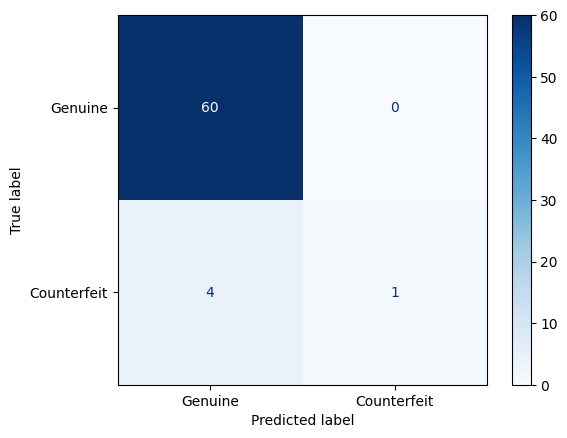

In [13]:

from sklearn.ensemble import RandomForestClassifier

# Standardize the distance vectors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

y_pred = clf.predict(X_test_scaled)
print("Classification Report on Independent Test Set (65 Images):")
print(classification_report(y_test, y_pred))

cmd = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Genuine', 'Counterfeit'])
cmd.plot(cmap='Blues')
plt.show()


In [17]:
from collections import Counter
from imblearn.over_sampling import SMOTE
import xgboost as xgb


Original Train shape: Counter({np.int64(0): 3940, np.int64(1): 132})
SMOTE Train shape: Counter({np.int64(1): 3940, np.int64(0): 3940})

--- NEW TUNED RESULTS (XGBoost + SMOTE + 0.2 Threshold) ---
              precision    recall  f1-score   support

           0       0.95      0.92      0.93        60
           1       0.29      0.40      0.33         5

    accuracy                           0.88        65
   macro avg       0.62      0.66      0.63        65
weighted avg       0.90      0.88      0.89        65



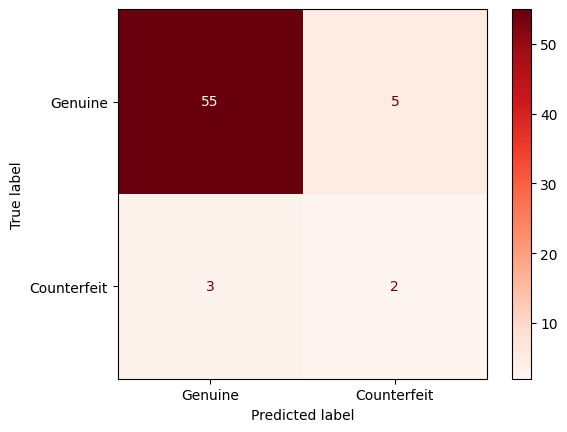

In [18]:
# pip install imbalanced-learn 
# (Run the line above in your terminal if you don't have it installed)

from imblearn.over_sampling import SMOTE
import xgboost as xgb

# 1. Apply SMOTE to physically balance the training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Train shape: {Counter(y_train)}")
print(f"SMOTE Train shape: {Counter(y_train_smote)}")

# 2. Train XGBoost instead of Random Forest
# scale_pos_weight forces the model to treat making a mistake on Class 1 as extremely bad!
ratio = float(np.sum(y_train_smote == 0)) / np.sum(y_train_smote == 1)
clf_xgb = xgb.XGBClassifier(n_estimators=200, scale_pos_weight=ratio, random_state=42)
clf_xgb.fit(X_train_smote, y_train_smote)

# 3. Decision Threshold Tuning (Shift from 0.50 -> 0.20)
# We ask for the raw probabilities instead of a direct prediction
y_pred_prob = clf_xgb.predict_proba(X_test_scaled)[:, 1] # Probability of being Counterfeit

# We declare it Counterfeit if it is more than 20% suspicious (0.20 threshold)
custom_threshold = 0.20
y_pred_tuned = (y_pred_prob >= custom_threshold).astype(int)

print("\n--- NEW TUNED RESULTS (XGBoost + SMOTE + 0.2 Threshold) ---")
print(classification_report(y_test, y_pred_tuned))

cmd = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned), display_labels=['Genuine', 'Counterfeit'])
cmd.plot(cmap='Reds')
plt.show()


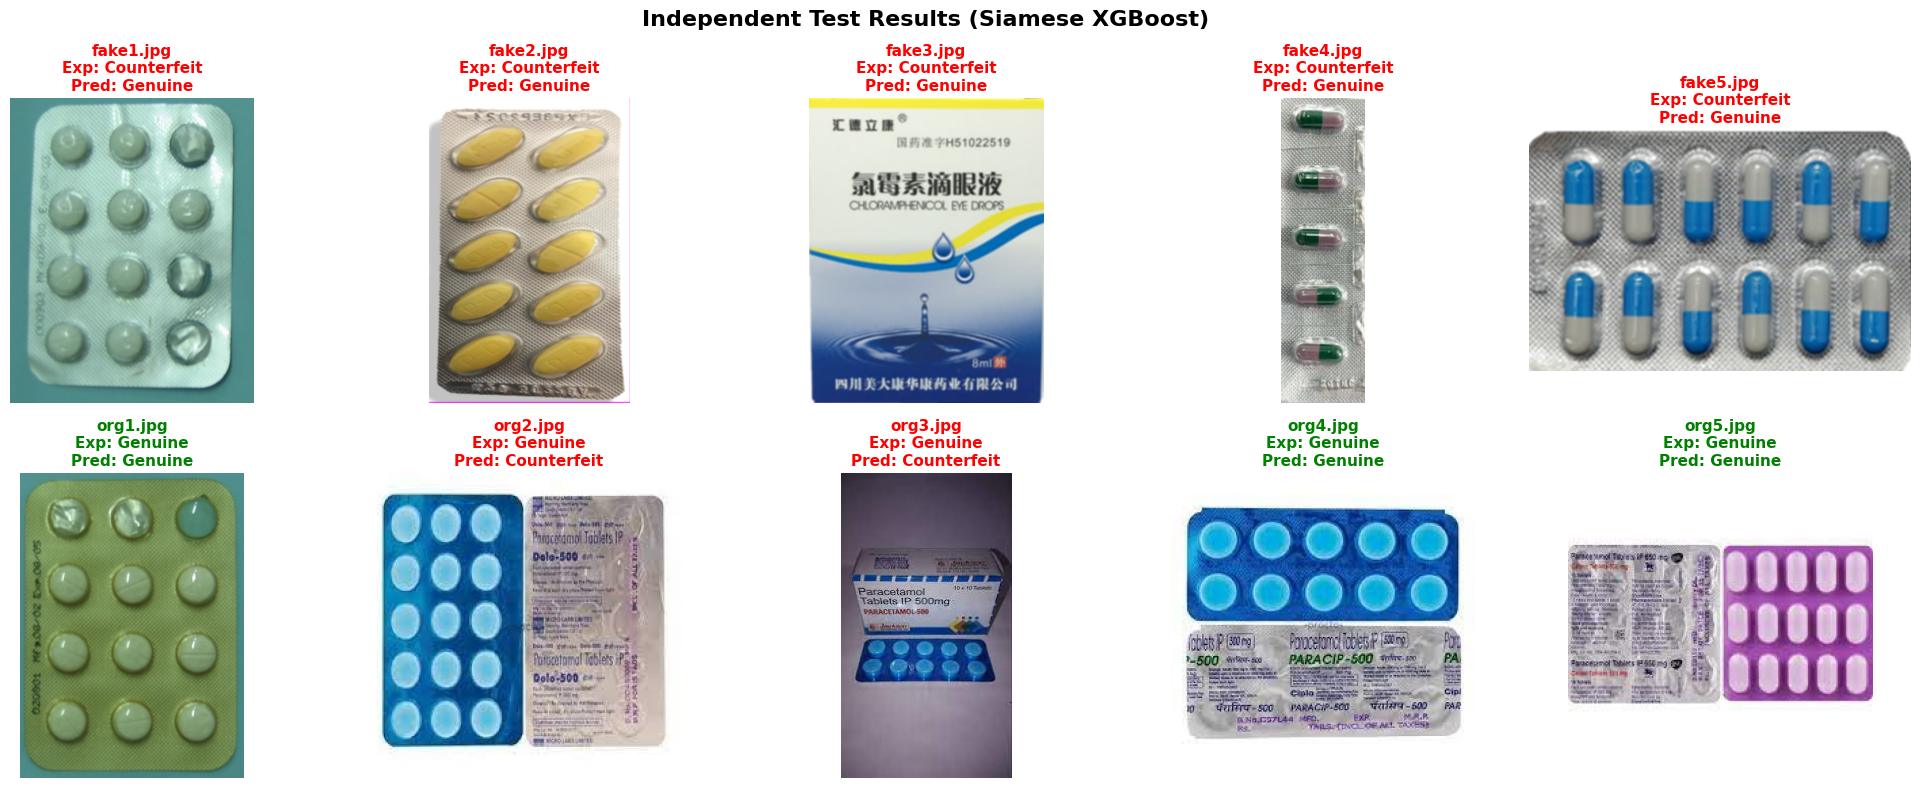

In [20]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

ind_test_dir = 'ind_test'

# UPDATE THIS DICTIONARY to perfectly match the 10 files inside your ind_test folder.
# 0 = Genuine, 1 = Counterfeit
ind_test_gt = {
    'fake1.jpg': {'expected': 1},
    'fake2.jpg': {'expected': 1},
    'fake3.jpg': {'expected': 1},
    'fake4.jpg': {'expected': 1},
    'fake5.jpg': {'expected': 1},
    'org1.jpg': {'expected': 0},
    'org2.jpg': {'expected': 0},
    'org3.jpg': {'expected': 0},
    'org4.jpg': {'expected': 0},
    'org5.jpg': {'expected': 0}
}

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, img_file in enumerate(sorted(ind_test_gt.keys())):
    if idx >= 10: break # Keep it strictly to the 2x5 grid
        
    row_idx = idx // 5
    col_idx = idx % 5
    ax = axes[row_idx, col_idx]

    img_path = os.path.join(ind_test_dir, img_file)
    img = cv2.imread(img_path)
    if img is None:
        ax.set_title(f"Cannot load\n{img_file}", color='red')
        ax.axis('off')
        continue
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    
    # 1. Siamese Inference Pipeline for this Single Image
    crop = extract_pill_roi(img_path, yolo_model)
    if crop is not None:
        vis_feat = extract_visual_features(crop)
        text = extract_ocr_text(crop)
        
        # Calculate distance against the Golden Reference
        vis_dist = np.abs(vis_feat - golden_vis_feat)
        text_dist = Levenshtein.distance(golden_text, text)
        final_feat = np.append(vis_dist, text_dist)
        
        # Scale and Predict
        final_feat_scaled = scaler.transform([final_feat])
        prob = clf_xgb.predict_proba(final_feat_scaled)[0, 1]
        
        # Apply our tuned 0.20 healthcare threshold limit
        pred_class = 1 if prob >= 0.20 else 0
        pred_label = "Counterfeit" if pred_class == 1 else "Genuine"
    else:
        pred_class = -1
        pred_label = "No Pill Detected"

    # 2. Evaluation & Validation
    gt_class = ind_test_gt[img_file]['expected']
    gt_label = "Counterfeit" if gt_class == 1 else "Genuine"
    
    correct = "OK" if pred_class == gt_class else "WRONG"
    color = 'green' if correct == 'OK' else 'red'
    
    ax.set_title(f'{img_file}\nExp: {gt_label}\nPred: {pred_label}',
                 fontsize=11, color=color, fontweight='bold')
    ax.axis('off')

plt.suptitle('Independent Test Results (Siamese XGBoost)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('ind_test_results.png', dpi=150, bbox_inches='tight')
plt.show()
